# Stock Data Visualizations
The notebooks includes:
- Mean next-day return by ticker with 95% confidence intervals
- A 60-day rolling mean return plot with 95% confidence bands
- Split-wise comparison of next-day returns with 95% confidence intervals



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

df = pd.read_csv("preprocessed_stock_data.csv", parse_dates=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df.head()

,Date,Open,High,Low,Close,Volume,Ticker,Log_Close,Log_Return,Simple_Return,...,Momentum_10,MA_Gap_10,Rolling_Vol_20,Momentum_20,MA_Gap_20,Rolling_Vol_60,Momentum_60,MA_Gap_60,Drawdown_20,Split
0,2010-03-31,7.049493,7.083020,7.018659,7.034823,430659600,AAPL,1.950873,-0.003611,-0.003605,...,0.047403,0.026124,0.011924,0.115673,0.041833,0.017348,0.093563,0.114787,-0.003605,train
1,2010-04-01,7.106970,7.146485,6.967471,7.063863,603145200,AAPL,1.954992,0.004120,0.004128,...,0.049161,0.025292,0.011928,0.113222,0.040308,0.017351,0.095955,0.117482,0.000000,train
2,2010-04-05,7.034229,7.139901,7.027942,7.139302,684507600,AAPL,1.965615,0.010623,0.010680,...,0.070525,0.028981,0.009235,0.085484,0.046909,0.017233,0.122612,0.126968,0.000000,train
3,2010-04-06,7.130617,7.191686,7.094695,7.170731,447017200,AAPL,1.970008,0.004393,0.004402,...,0.063731,0.026958,0.009194,0.089284,0.046817,0.017228,0.128855,0.129353,0.000000,train
4,2010-04-07,7.171031,7.241978,7.144388,7.202464,628502000,AAPL,1.974423,0.004416,0.004425,...,0.052212,0.026118,0.008641,0.075874,0.047426,0.017221,0.126644,0.131806,0.000000,train


In [2]:
def mean_ci(series: pd.Series, confidence: float = 0.95) -> pd.Series:
    clean = series.dropna()
    n = clean.shape[0]
    mean = clean.mean()
    std = clean.std(ddof=1)
    se = std / np.sqrt(n)
    z = 1.96 if confidence == 0.95 else 1.96
    lower = mean - z * se
    upper = mean + z * se
    return pd.Series({
        "n": n,
        "mean": mean,
        "std": std,
        "se": se,
        "ci_lower": lower,
        "ci_upper": upper,
    })

ticker_return_summary = (
    df.groupby("Ticker")["Next_Day_Log_Return"]
      .apply(mean_ci)
      .unstack()
      .reset_index()
)

ticker_return_summary

,Ticker,n,mean,std,se,ci_lower,ci_upper
0,AAPL,3963.0,0.000922,0.017746,0.000282,0.000369,0.001474
1,IBM,3963.0,0.000361,0.014437,0.000229,-0.000089,0.000810
2,MSFT,3963.0,0.000780,0.016106,0.000256,0.000278,0.001281


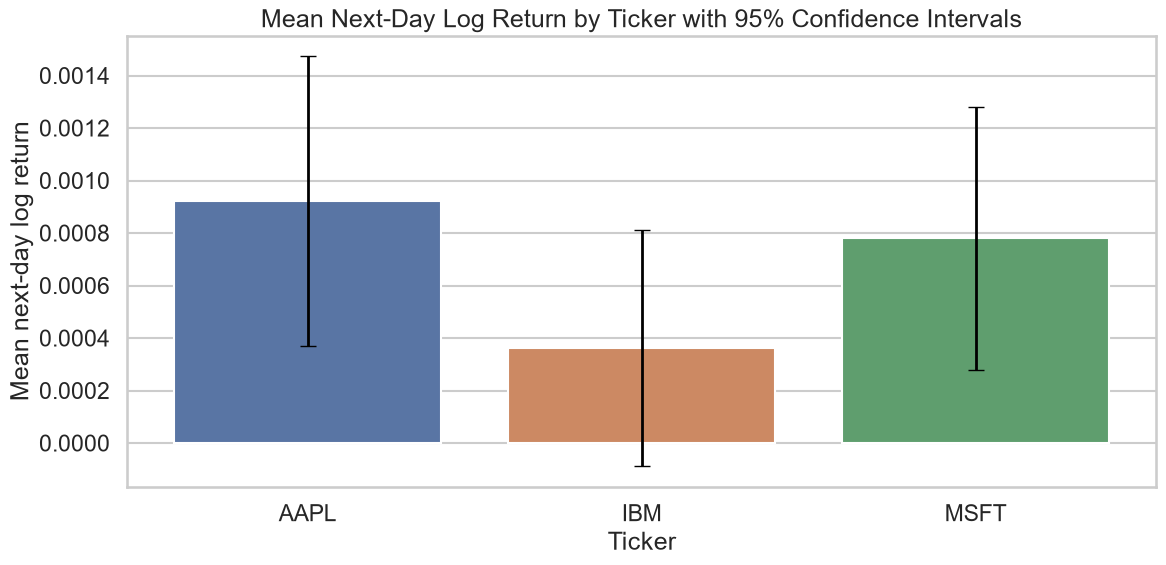

In [3]:
ax = sns.barplot(
    data=ticker_return_summary,
    x="Ticker",
    y="mean",
    hue="Ticker",
    palette="deep",
    errorbar=None,
    legend=False
)

ax.errorbar(
    x=np.arange(len(ticker_return_summary)),
    y=ticker_return_summary["mean"],
    yerr=[
        ticker_return_summary["mean"] - ticker_return_summary["ci_lower"],
        ticker_return_summary["ci_upper"] - ticker_return_summary["mean"],
    ],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=6
)

ax.set_title("Mean Next-Day Log Return by Ticker with 95% Confidence Intervals")
ax.set_xlabel("Ticker")
ax.set_ylabel("Mean next-day log return")
plt.tight_layout()
plt.show()

AAPL and MSFT appear to have stronger average next-day returns than IBM, but the confidence intervals are wide, so the differences should not be treated as very strong evidence.

KeyError: 'Ticker'

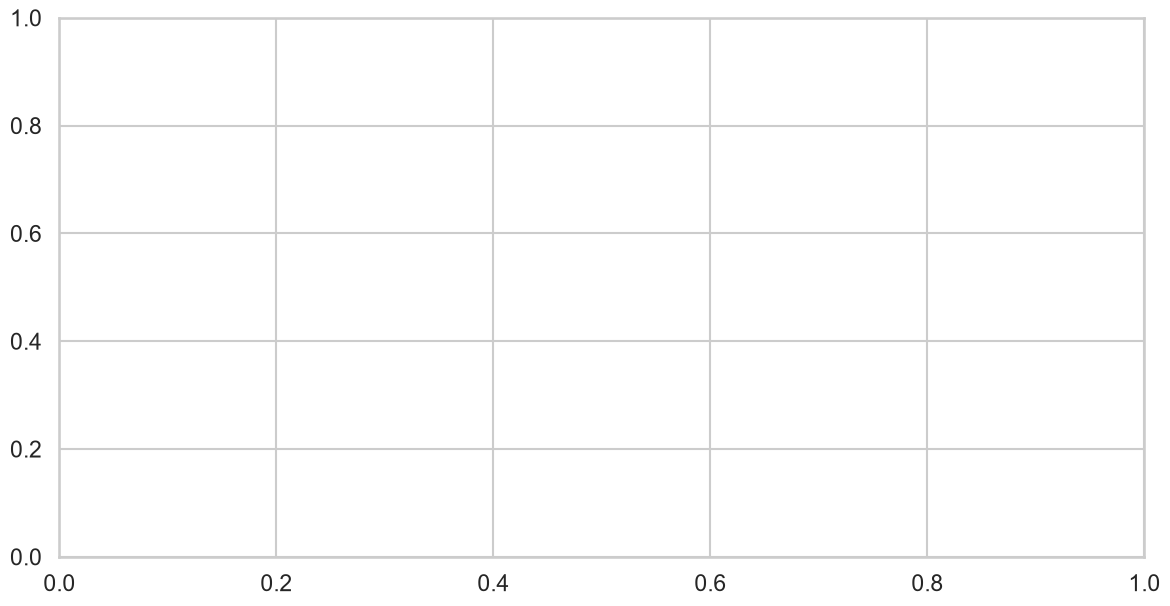

In [4]:
def add_rolling_ci(group: pd.DataFrame, column: str = "Log_Return", window: int = 60) -> pd.DataFrame:
    g = group.sort_values("Date").copy()
    rolling_mean = g[column].rolling(window).mean()
    rolling_std = g[column].rolling(window).std(ddof=1)
    rolling_n = g[column].rolling(window).count()
    rolling_se = rolling_std / np.sqrt(rolling_n)
    margin = 1.96 * rolling_se

    g["rolling_mean"] = rolling_mean
    g["ci_lower"] = rolling_mean - margin
    g["ci_upper"] = rolling_mean + margin
    return g

rolling_plot_df = (
    df.groupby("Ticker", group_keys=False)
      .apply(add_rolling_ci, column="Log_Return", window=60)
)

fig, ax = plt.subplots(figsize=(14, 7))
palette = sns.color_palette("deep", n_colors=rolling_plot_df["Ticker"].nunique())

for color, ticker in zip(palette, sorted(rolling_plot_df["Ticker"].unique())):
    ticker_df = rolling_plot_df.loc[rolling_plot_df["Ticker"] == ticker].dropna(subset=["rolling_mean"])
    ax.plot(ticker_df["Date"], ticker_df["rolling_mean"], label=ticker, color=color, linewidth=2)
    ax.fill_between(
        ticker_df["Date"],
        ticker_df["ci_lower"],
        ticker_df["ci_upper"],
        color=color,
        alpha=0.18
    )

ax.set_title("60-Day Rolling Mean Log Return with 95% Confidence Bands")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling mean log return")
ax.legend(title="Ticker")
plt.tight_layout()
plt.show()

the next day return is noisy, and unstable 


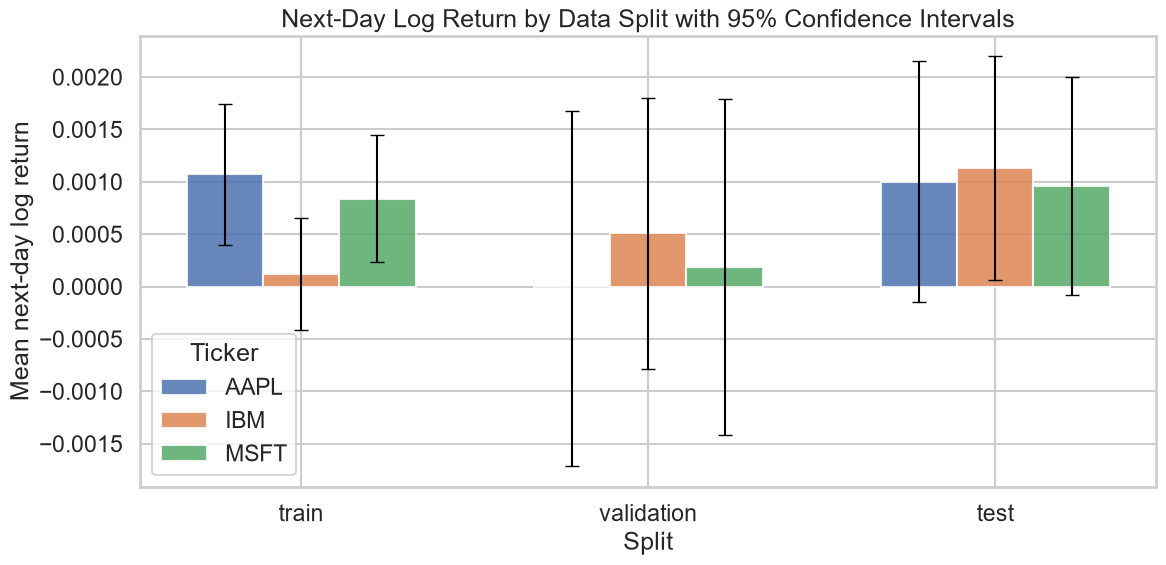

In [5]:
split_return_summary = (
    df.groupby(["Ticker", "Split"])["Next_Day_Log_Return"]
      .apply(mean_ci)
      .unstack()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
order = ["train", "validation", "test"]
tickers = sorted(split_return_summary["Ticker"].unique())
x = np.arange(len(order))
width = 0.22
palette = sns.color_palette("deep", n_colors=len(tickers))

for i, (ticker, color) in enumerate(zip(tickers, palette)):
    ticker_df = split_return_summary.loc[split_return_summary["Ticker"] == ticker].set_index("Split").reindex(order)
    xpos = x + (i - 1) * width
    ax.bar(xpos, ticker_df["mean"], width=width, label=ticker, color=color, alpha=0.85)
    ax.errorbar(
        xpos,
        ticker_df["mean"],
        yerr=[
            ticker_df["mean"] - ticker_df["ci_lower"],
            ticker_df["ci_upper"] - ticker_df["mean"],
        ],
        fmt="none",
        ecolor="black",
        elinewidth=1.5,
        capsize=5
    )

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title("Next-Day Log Return by Data Split with 95% Confidence Intervals")
ax.set_xlabel("Split")
ax.set_ylabel("Mean next-day log return")
ax.legend(title="Ticker")
plt.tight_layout()
plt.show()

## Daily vs Weekly Return Noise by Stock

The following section adapts the daily-vs-weekly return visualization so it runs for every stock in the dataset. It compares daily log returns with weekly log returns and saves one 2x2 figure per ticker.

In [6]:
from pathlib import Path

# Daily-vs-weekly visualization settings
daily_df = df.copy()

weekly_data_path = Path("outputs") / "weekly" / "model_df_weekly.csv"
if not weekly_data_path.exists():
    weekly_data_path = Path("outputs") / "weekly" / "weekly_features_df.csv"
if not weekly_data_path.exists():
    raise FileNotFoundError("Could not find weekly data under outputs/weekly/.")

weekly_df = pd.read_csv(weekly_data_path, parse_dates=["Date"])
weekly_df = weekly_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

date_col = "Date"
ticker_col = "Ticker"
daily_return_col = "Log_Return"
weekly_return_col = "Weekly_Log_Return"

start_date = pd.Timestamp("2018-01-01")
end_date = pd.Timestamp("2025-12-31")

daily_weekly_plot_dir = Path("outputs") / "visualizations" / "daily_vs_weekly_returns"
daily_weekly_plot_dir.mkdir(parents=True, exist_ok=True)

required_daily_cols = {date_col, ticker_col, daily_return_col}
required_weekly_cols = {date_col, ticker_col, weekly_return_col}
missing_daily = sorted(required_daily_cols.difference(daily_df.columns))
missing_weekly = sorted(required_weekly_cols.difference(weekly_df.columns))
if missing_daily:
    raise ValueError(f"daily_df is missing required columns: {missing_daily}")
if missing_weekly:
    raise ValueError(f"weekly_df is missing required columns: {missing_weekly}")

daily_df[date_col] = pd.to_datetime(daily_df[date_col])
weekly_df[date_col] = pd.to_datetime(weekly_df[date_col])

tickers_to_plot = sorted(set(daily_df[ticker_col]).intersection(weekly_df[ticker_col]))
if not tickers_to_plot:
    raise ValueError("No overlapping tickers found between daily_df and weekly_df.")

print(f"Weekly data source: {weekly_data_path}")
print(f"Tickers to plot: {tickers_to_plot}")
print(f"Saving figures to: {daily_weekly_plot_dir}")

Weekly data source: outputs\weekly\model_df_weekly.csv
Tickers to plot: ['AAPL', 'IBM', 'MSFT']
Saving figures to: outputs\visualizations\daily_vs_weekly_returns


In [ ]:
def return_summary(series: pd.Series) -> dict[str, float]:
    clean = series.dropna()
    return {
        "n": int(clean.shape[0]),
        "mean": float(clean.mean()),
        "std": float(clean.std(ddof=1)),
        "positive_share": float((clean > 0).mean()),
        "non_positive_share": float((clean <= 0).mean()),
    }


def plot_daily_vs_weekly_returns_for_ticker(
    ticker: str,
    daily_data: pd.DataFrame,
    weekly_data: pd.DataFrame,
    output_dir: Path,
    show_plot: bool = True,
) -> dict[str, object]:
    daily_plot = (
        daily_data.loc[
            (daily_data[ticker_col] == ticker)
            & (daily_data[date_col] >= start_date)
            & (daily_data[date_col] <= end_date)
        ]
        .sort_values(date_col)
        .dropna(subset=[daily_return_col])
        .copy()
    )
    weekly_plot = (
        weekly_data.loc[
            (weekly_data[ticker_col] == ticker)
            & (weekly_data[date_col] >= start_date)
            & (weekly_data[date_col] <= end_date)
        ]
        .sort_values(date_col)
        .dropna(subset=[weekly_return_col])
        .copy()
    )

    if daily_plot.empty:
        raise ValueError(f"No daily rows available for {ticker} in the selected date range.")
    if weekly_plot.empty:
        raise ValueError(f"No weekly rows available for {ticker} in the selected date range.")

    daily_stats = return_summary(daily_plot[daily_return_col])
    weekly_stats = return_summary(weekly_plot[weekly_return_col])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(
        f"{ticker}: Daily Returns Are Noisier Than Weekly Returns",
        fontsize=18,
        fontweight="bold",
        y=0.985,
    )

    ax = axes[0, 0]
    ax.plot(daily_plot[date_col], daily_plot[daily_return_col], color="#1f77b4", linewidth=1.0, alpha=0.85)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Daily log returns over time")
    ax.set_xlabel("")
    ax.set_ylabel("Daily log return")

    ax = axes[0, 1]
    ax.plot(weekly_plot[date_col], weekly_plot[weekly_return_col], color="#ff7f0e", linewidth=1.8, alpha=0.9)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Weekly log returns over time")
    ax.set_xlabel("")
    ax.set_ylabel("Weekly log return")

    ax = axes[1, 0]
    sns.histplot(
        daily_plot[daily_return_col],
        bins=60,
        kde=True,
        stat="density",
        color="#1f77b4",
        alpha=0.65,
        edgecolor="white",
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(daily_stats["mean"], color="#d62728", linestyle="-", linewidth=2)
    ax.set_title("Distribution of daily log returns")
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Density")

    ax = axes[1, 1]
    sns.histplot(
        weekly_plot[weekly_return_col],
        bins=40,
        kde=True,
        stat="density",
        color="#ff7f0e",
        alpha=0.65,
        edgecolor="white",
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(weekly_stats["mean"], color="#d62728", linestyle="-", linewidth=2)
    ax.set_title("Distribution of weekly log returns")
    ax.set_xlabel("Weekly log return")
    ax.set_ylabel("Density")

    plt.tight_layout(rect=[0, 0.02, 1, 0.94], h_pad=2.0, w_pad=2.0)

    output_path = output_dir / f"{ticker}_daily_vs_weekly_return_noise.png"
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    if show_plot:
        plt.show()
    plt.close(fig)

    return {
        "Ticker": ticker,
        "daily_rows": daily_stats["n"],
        "weekly_rows": weekly_stats["n"],
        "daily_mean": daily_stats["mean"],
        "daily_std": daily_stats["std"],
        "daily_positive_share": daily_stats["positive_share"],
        "weekly_mean": weekly_stats["mean"],
        "weekly_std": weekly_stats["std"],
        "weekly_positive_share": weekly_stats["positive_share"],
        "std_ratio_daily_to_weekly": daily_stats["std"] / weekly_stats["std"],
        "plot_path": str(output_path),
    }

In [ ]:
daily_weekly_summary_rows = []

for ticker in tickers_to_plot:
    daily_weekly_summary_rows.append(
        plot_daily_vs_weekly_returns_for_ticker(
            ticker=ticker,
            daily_data=daily_df,
            weekly_data=weekly_df,
            output_dir=daily_weekly_plot_dir,
            show_plot=True,
        )
    )

daily_weekly_summary_df = pd.DataFrame(daily_weekly_summary_rows)
daily_weekly_summary_path = daily_weekly_plot_dir / "daily_vs_weekly_return_noise_summary.csv"
daily_weekly_summary_df.to_csv(daily_weekly_summary_path, index=False)

display(daily_weekly_summary_df)
print(f"Saved summary to: {daily_weekly_summary_path}")

## Interpretation Notes

- If a confidence interval is narrow, the mean estimate is more stable.
- If confidence intervals across groups overlap heavily, the differences may be small relative to the noise.
- For a stronger financial inference workflow later, consider block bootstrap confidence intervals or Newey-West adjusted standard errors.